In [ ]:
Importing Libraries:

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
Dataset Loading:

In [2]:
mobiles = pd.read_csv(r"E:\mobile_price_predictioin\cell.csv")
mobiles

,brand,ram_gb,storage_gb,battery_mah,primary_camera_mp,front_camera_mp,screen_size_inch,weight_g,fiveg,price_inr
0,Oppo,3,64,4814,50,12,6.79,196,0,17009
1,OnePlus,3,64,5648,108,16,5.62,215,1,21954
2,Realme,3,64,5426,64,32,6.26,187,0,11985
3,Oppo,12,256,4201,108,16,6.24,181,1,37203
4,Xiaomi,8,32,4450,50,8,5.48,166,1,27006
...,...,...,...,...,...,...,...,...,...,...
995,Realme,8,32,5257,48,8,5.34,184,1,28513
996,Samsung,4,64,5761,108,32,5.53,221,0,16710
997,OnePlus,4,256,5349,12,8,5.87,197,1,17897
998,Motorola,4,128,4932,64,12,5.90,159,1,14582


In [ ]:
EDA(Elploratory Data Analysis):

In [3]:
mobiles.head()

,brand,ram_gb,storage_gb,battery_mah,primary_camera_mp,front_camera_mp,screen_size_inch,weight_g,fiveg,price_inr
0,Oppo,3,64,4814,50,12,6.79,196,0,17009
1,OnePlus,3,64,5648,108,16,5.62,215,1,21954
2,Realme,3,64,5426,64,32,6.26,187,0,11985
3,Oppo,12,256,4201,108,16,6.24,181,1,37203
4,Xiaomi,8,32,4450,50,8,5.48,166,1,27006


In [4]:
mobiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              1000 non-null   object 
 1   ram_gb             1000 non-null   int64  
 2   storage_gb         1000 non-null   int64  
 3   battery_mah        1000 non-null   int64  
 4   primary_camera_mp  1000 non-null   int64  
 5   front_camera_mp    1000 non-null   int64  
 6   screen_size_inch   1000 non-null   float64
 7   weight_g           1000 non-null   int64  
 8   fiveg              1000 non-null   int64  
 9   price_inr          1000 non-null   int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 78.3+ KB


In [5]:
mobiles.shape

(1000, 10)

In [6]:
mobiles.isna().sum()

brand                0
ram_gb               0
storage_gb           0
battery_mah          0
primary_camera_mp    0
front_camera_mp      0
screen_size_inch     0
weight_g             0
fiveg                0
price_inr            0
dtype: int64

In [7]:
mobiles.dtypes

brand                 object
ram_gb                 int64
storage_gb             int64
battery_mah            int64
primary_camera_mp      int64
front_camera_mp        int64
screen_size_inch     float64
weight_g               int64
fiveg                  int64
price_inr              int64
dtype: object

In [ ]:
Droping Features:

In [8]:
mobiles = mobiles.drop(['brand'],axis=1)

In [9]:
mobiles

,ram_gb,storage_gb,battery_mah,primary_camera_mp,front_camera_mp,screen_size_inch,weight_g,fiveg,price_inr
0,3,64,4814,50,12,6.79,196,0,17009
1,3,64,5648,108,16,5.62,215,1,21954
2,3,64,5426,64,32,6.26,187,0,11985
3,12,256,4201,108,16,6.24,181,1,37203
4,8,32,4450,50,8,5.48,166,1,27006
...,...,...,...,...,...,...,...,...,...
995,8,32,5257,48,8,5.34,184,1,28513
996,4,64,5761,108,32,5.53,221,0,16710
997,4,256,5349,12,8,5.87,197,1,17897
998,4,128,4932,64,12,5.90,159,1,14582


In [ ]:
Linearity Check:

In [12]:
features = ['ram_gb','storage_gb','battery_mah','primary_camera_mp','front_camera_mp','screen_size_inch','weight_g','fiveg']
target = 'price_inr' 

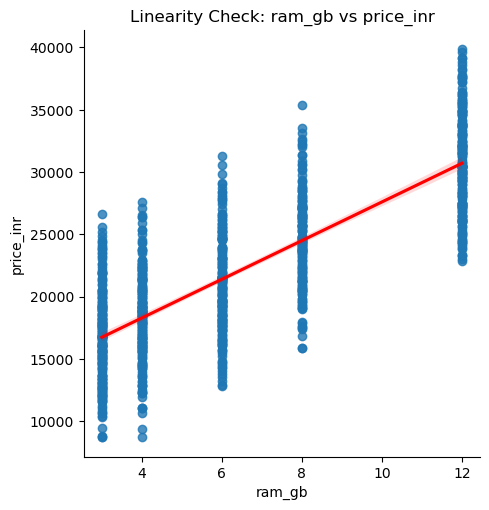

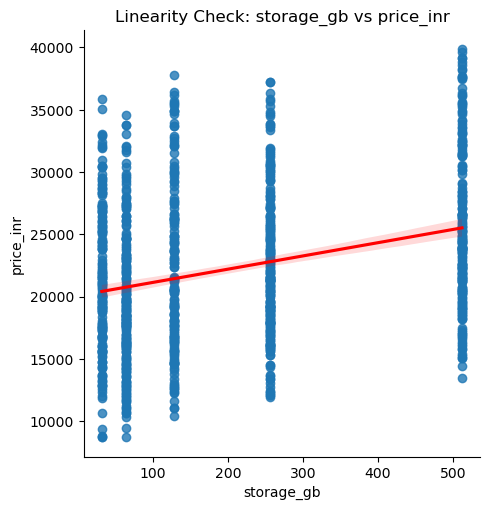

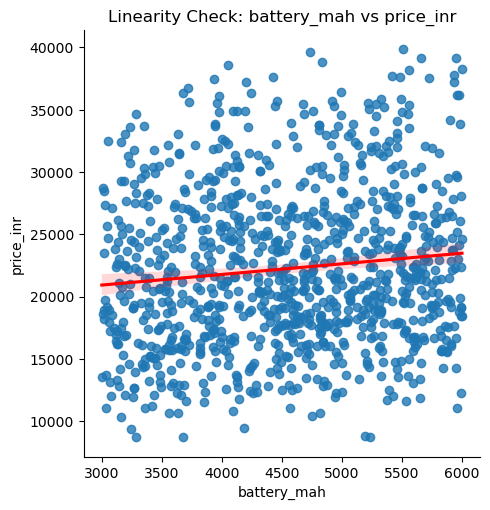

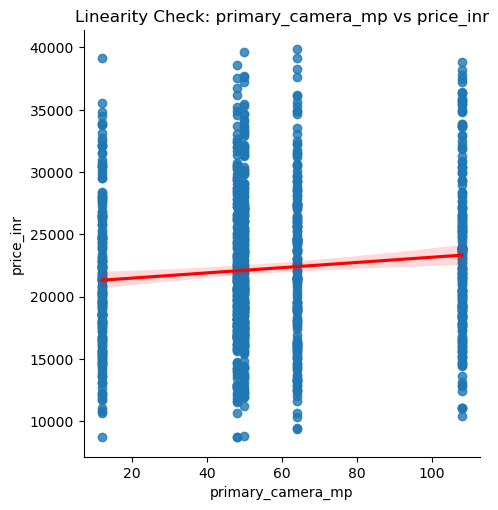

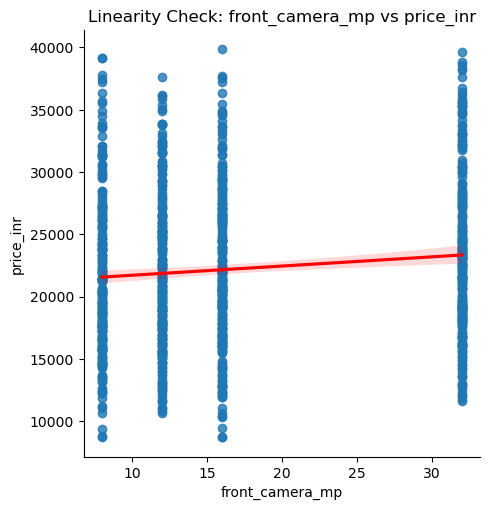

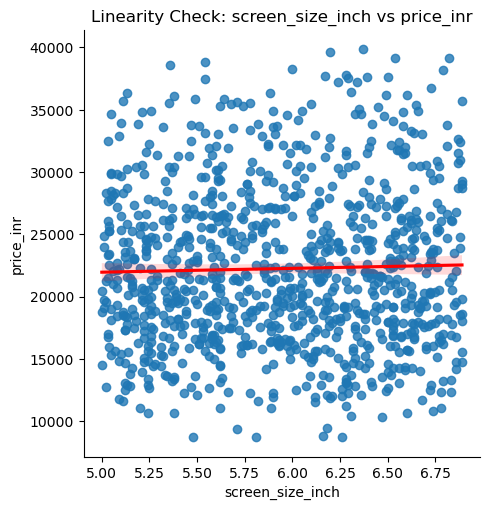

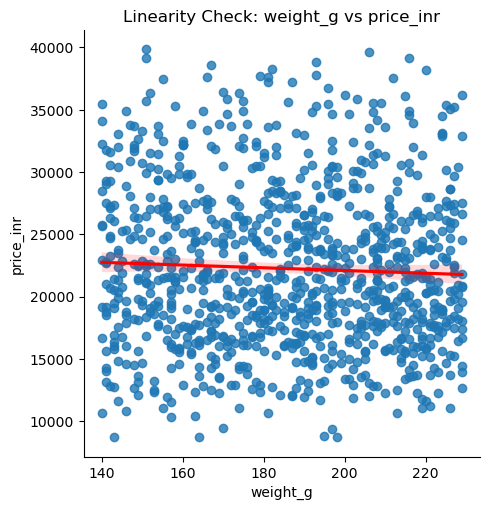

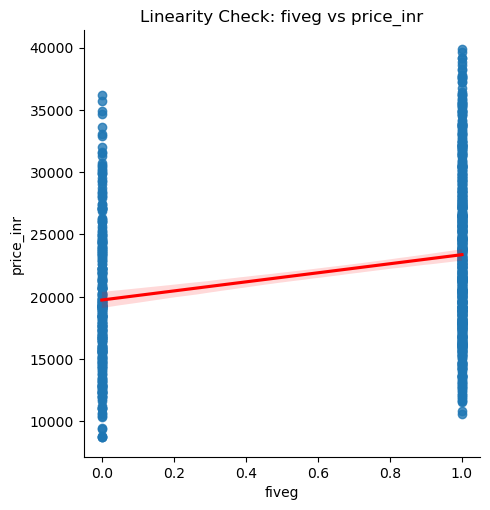

In [13]:
for col in features:
    sns.lmplot(x=col, y=target, data=mobiles, line_kws={'color': 'red'})
    plt.title(f"Linearity Check: {col} vs {target}")
    plt.show()

In [14]:
mobiles.corr()

,ram_gb,storage_gb,battery_mah,primary_camera_mp,front_camera_mp,screen_size_inch,weight_g,fiveg,price_inr
ram_gb,1.000000,-0.016342,-0.024188,-0.005688,0.029791,0.008167,-0.066595,0.048380,0.796557
storage_gb,-0.016342,1.000000,0.009087,0.081812,0.134978,0.014553,0.017719,0.042766,0.295127
battery_mah,-0.024188,0.009087,1.000000,0.022019,0.023090,-0.028106,0.065509,0.036467,0.112919
primary_camera_mp,-0.005688,0.081812,0.022019,1.000000,0.052300,-0.061118,-0.048233,0.000833,0.102910
front_camera_mp,0.029791,0.134978,0.023090,0.052300,1.000000,-0.018791,-0.011046,0.017133,0.106425
screen_size_inch,0.008167,0.014553,-0.028106,-0.061118,-0.018791,1.000000,-0.042192,0.022650,0.026362
weight_g,-0.066595,0.017719,0.065509,-0.048233,-0.011046,-0.042192,1.000000,0.012928,-0.044513
fiveg,0.048380,0.042766,0.036467,0.000833,0.017133,0.022650,0.012928,1.000000,0.264657
price_inr,0.796557,0.295127,0.112919,0.102910,0.106425,0.026362,-0.044513,0.264657,1.000000


In [ ]:
Normality Check:

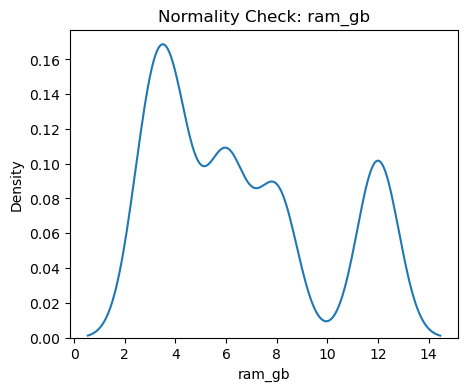

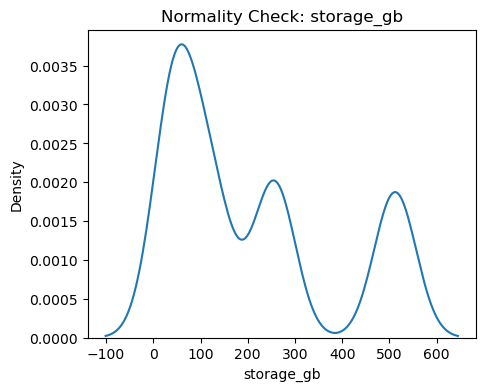

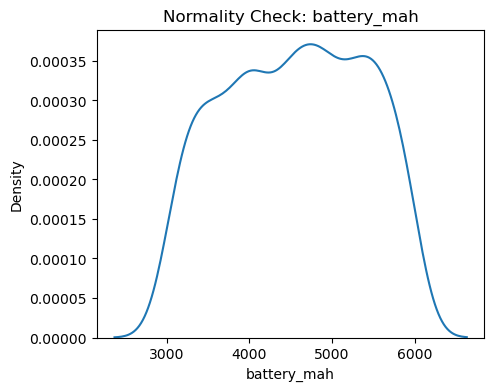

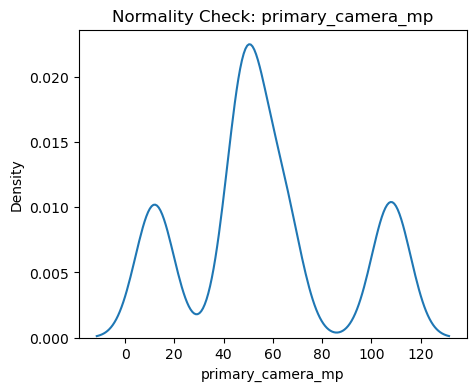

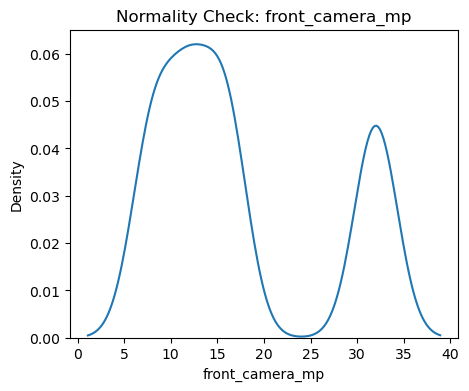

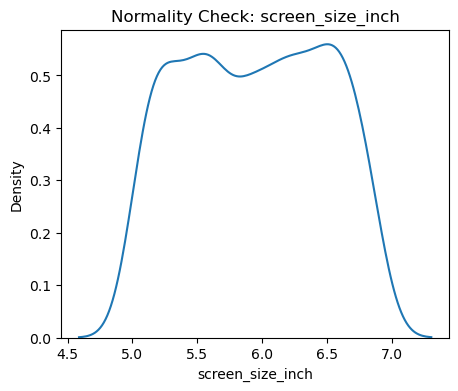

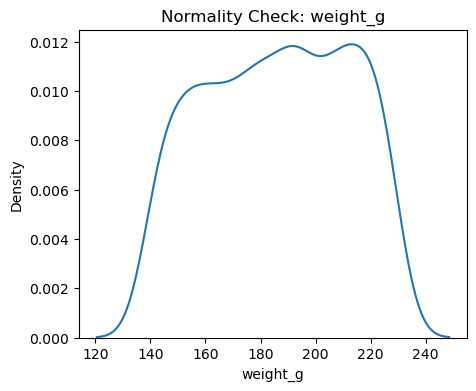

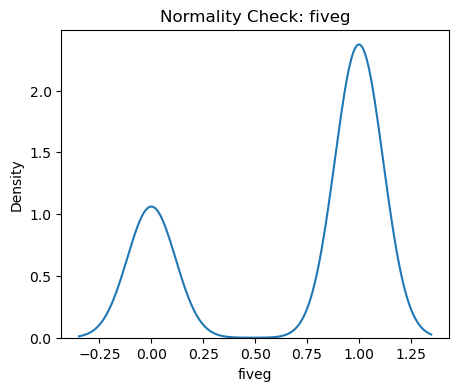

In [15]:
for col in features:
    plt.figure(figsize=(5, 4))
    sns.distplot(mobiles[col],hist=False)
    plt.title(f"Normality Check: {col}")
    plt.show()

In [ ]:
Model Building:

In [16]:
x = mobiles.drop(['price_inr'],axis=1)
x

,ram_gb,storage_gb,battery_mah,primary_camera_mp,front_camera_mp,screen_size_inch,weight_g,fiveg
0,3,64,4814,50,12,6.79,196,0
1,3,64,5648,108,16,5.62,215,1
2,3,64,5426,64,32,6.26,187,0
3,12,256,4201,108,16,6.24,181,1
4,8,32,4450,50,8,5.48,166,1
...,...,...,...,...,...,...,...,...
995,8,32,5257,48,8,5.34,184,1
996,4,64,5761,108,32,5.53,221,0
997,4,256,5349,12,8,5.87,197,1
998,4,128,4932,64,12,5.90,159,1


In [17]:
y=mobiles['price_inr']
y

0      17009
1      21954
2      11985
3      37203
4      27006
       ...  
995    28513
996    16710
997    17897
998    14582
999    22632
Name: price_inr, Length: 1000, dtype: int64

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=35)

In [19]:
mpp = LinearRegression() #model build
mpp.fit(x_train,y_train) #training the model
y_pred_train = mpp.predict(x_train) #test the model
y_pred_test = mpp.predict(x_test)

In [20]:
y_pred_train

array([15668.42859034, 17731.61779147, 28050.7722878 , 28218.08541313,
       22150.95997852, 17315.23540629, 20039.88351306, 19780.20646521,
       21374.53558932, 22647.35640946, 18513.33455349, 14221.47096121,
       24398.02799114, 21787.62807148, 25252.24425911, 18435.64011255,
       20477.71776032, 20169.82030948, 17600.93549007, 15751.25871338,
       14823.46203325, 16737.49536035, 20602.55385109, 20693.33843397,
       21990.88376495, 21429.45487669, 20072.16872055, 21996.46853947,
       17661.20919916, 28005.24841868, 18963.41362432, 26909.07288518,
       15373.92641861, 31118.80916291, 26587.82787685, 20704.44168872,
       20055.41722275, 14330.27677013, 35139.85566242, 21453.95714672,
       23141.38621614, 27412.71743061, 16141.15684684, 20245.41301175,
       20733.5705021 , 27430.85972001, 18995.56997839, 17595.1428812 ,
       16014.46692336, 28200.26522167, 27267.71612667, 23052.797322  ,
       20941.45066448, 17751.93665374, 31535.42487686, 26977.33242276,
      

In [21]:
y_pred_test

array([28896.81977622, 21753.7702633 , 22048.44660029, 26060.51571936,
       20370.08747385, 23488.85573057, 14677.15307022, 29372.90515883,
       25167.84640235, 20579.63631555, 34326.58545792, 12946.16653241,
       19641.73483326, 23666.05253201, 18477.58565725, 28555.83191317,
       20455.49373796, 23272.10397178, 11938.18113089, 15604.09509334,
       18175.6173524 , 24847.0284529 , 20510.73583054, 30215.80249786,
       22400.59101661, 21490.51986077, 22896.34747911, 26541.71297871,
       18116.38030163, 25301.67000213, 16867.30644829, 14899.13671615,
       24740.82548278, 25044.90318039, 26343.76795883, 22748.86069767,
       14628.68884101, 15356.43952675, 25792.71062211, 18250.01942952,
       28109.13009442, 19354.40247238, 22888.10607661, 22241.66508194,
       24074.2288655 , 23267.9193533 , 23330.83380582, 28935.50948168,
       17607.6035231 , 19009.85937814, 29894.92380907, 29479.22430535,
       16076.52939284, 16903.77921334, 18224.52104104, 15204.87751406,
      

In [22]:
error_train=y_train-y_pred_train
error_train

387     408.571410
528    3031.382209
697    4001.227712
626    -925.085413
729    -845.959979
          ...     
959     324.265205
33    -3586.922060
951   -3971.182071
271   -1949.715381
713   -2486.153598
Name: price_inr, Length: 700, dtype: float64

In [23]:
error_test=y_test-y_pred_test
error_test

832    1564.180224
617   -2789.770263
638    4588.553400
939    -549.515719
826    4630.912526
          ...     
652    4831.823379
653    2442.841799
833    3744.317278
971    -976.582269
980    3654.574418
Name: price_inr, Length: 300, dtype: float64

In [24]:
mpp_r2_train = r2_score(y_train,y_pred_train)
mpp_r2_train

0.7940900211218954

In [25]:
mpp_r2_test = r2_score(y_test,y_pred_test)
mpp_r2_test

0.800980491940426

In [ ]:
Homoscedacity Test:

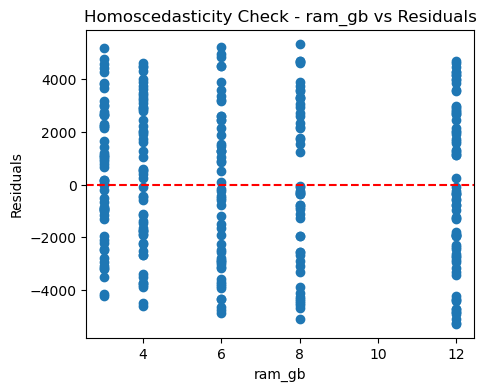

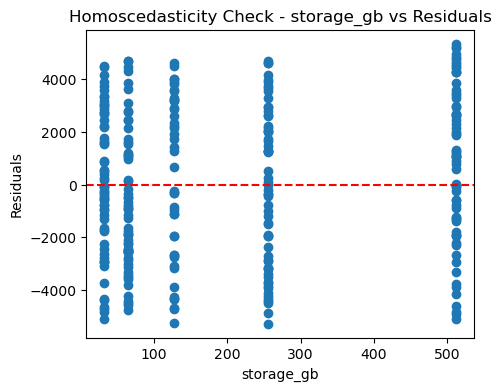

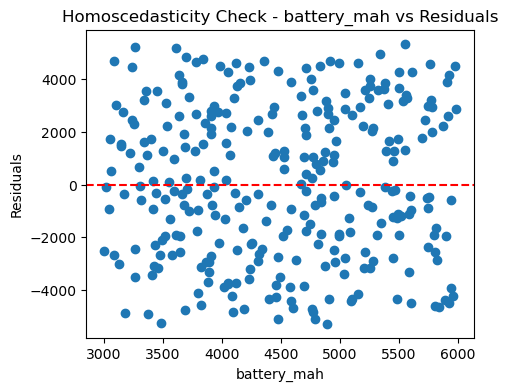

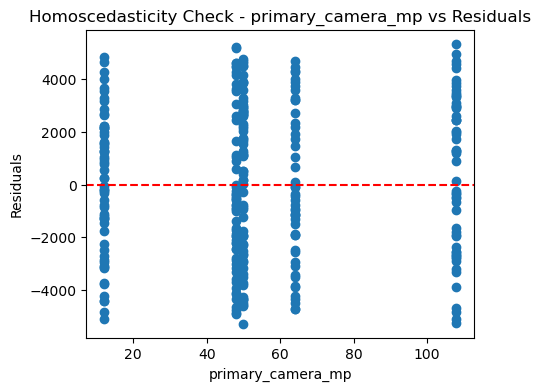

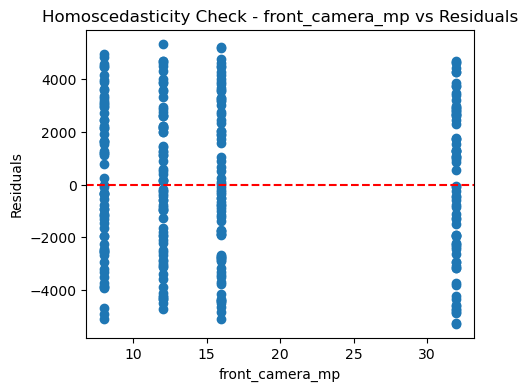

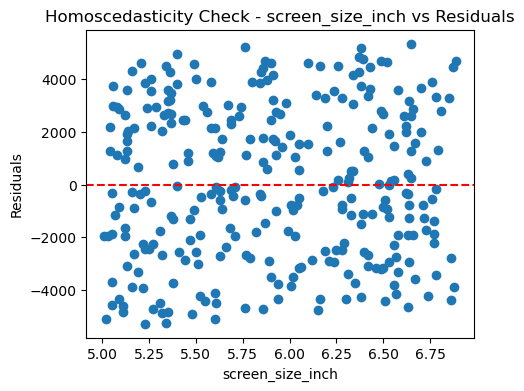

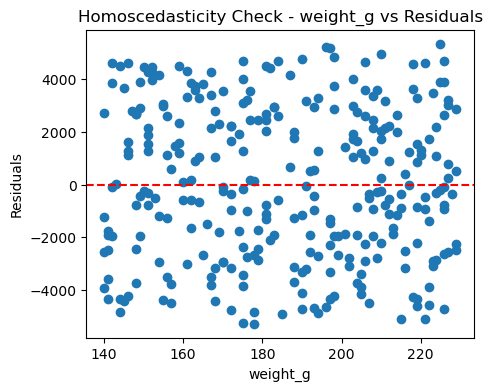

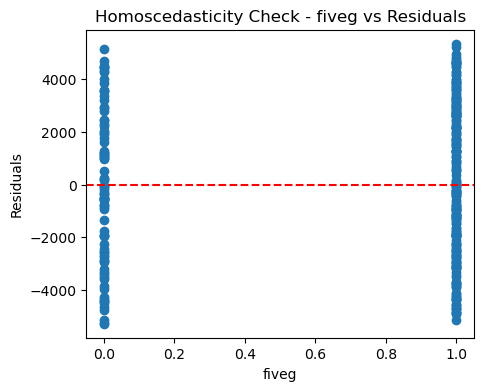

In [26]:
for col in features:
    plt.figure(figsize=(5,4))
    plt.scatter(x = x_test[col], y = error_test)
    plt.title(f'Homoscedasticity Check - {col} vs Residuals')
    plt.xlabel(col)
    plt.ylabel('Residuals')
    plt.axhline(0, color='red', linestyle='--')
    plt.show()

In [ ]:
Residuals-Normality Check:

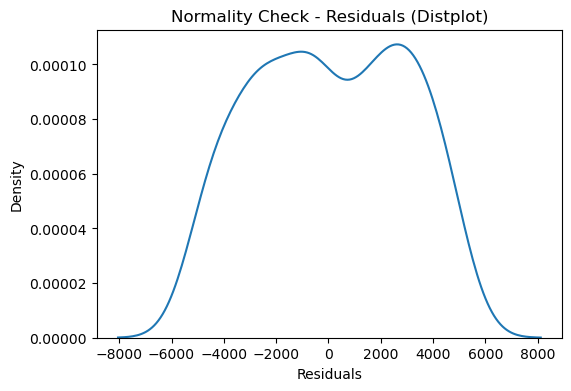

In [27]:
res = error_test.to_numpy()
res = res[np.isfinite(res)]

# Distplot for normality check
plt.figure(figsize=(6,4))
sns.distplot(res,hist=False)
plt.title("Normality Check - Residuals (Distplot)")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

In [ ]:
Ridge and Lasso:

In [28]:
l = Lasso()
l.fit(x_train,y_train)
y_train_pred = l.predict(x_train)
y_test_pred = l.predict(x_test)

In [29]:
Lasso_r2 = r2_score(y_test,y_test_pred)
Lasso_r2

0.8009636080265593

In [30]:
r = Ridge()
r.fit(x_train,y_train)
y_train_pred = r.predict(x_train)
y_test_pred = r.predict(x_test)

In [31]:
Ridge_r2 = r2_score(y_test,y_test_pred)
Ridge_r2

0.8009262261345048

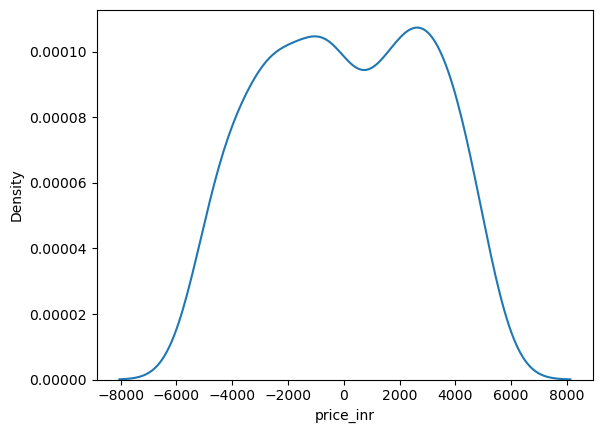

In [32]:
sns.distplot(a=error_test,hist = False)
plt.show()

In [ ]:
Creating a Pickle file:

In [33]:
### Create a Pickle file using serialization 
import pickle
pickle_out = open("mpp.pkl","wb")
pickle.dump(mpp, pickle_out)
pickle_out.close()